In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [32]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 3   # Espessura da linha
plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


# Aqui eu criei um código que encontra os vales para cada dado experimental obtido

## Gráficos

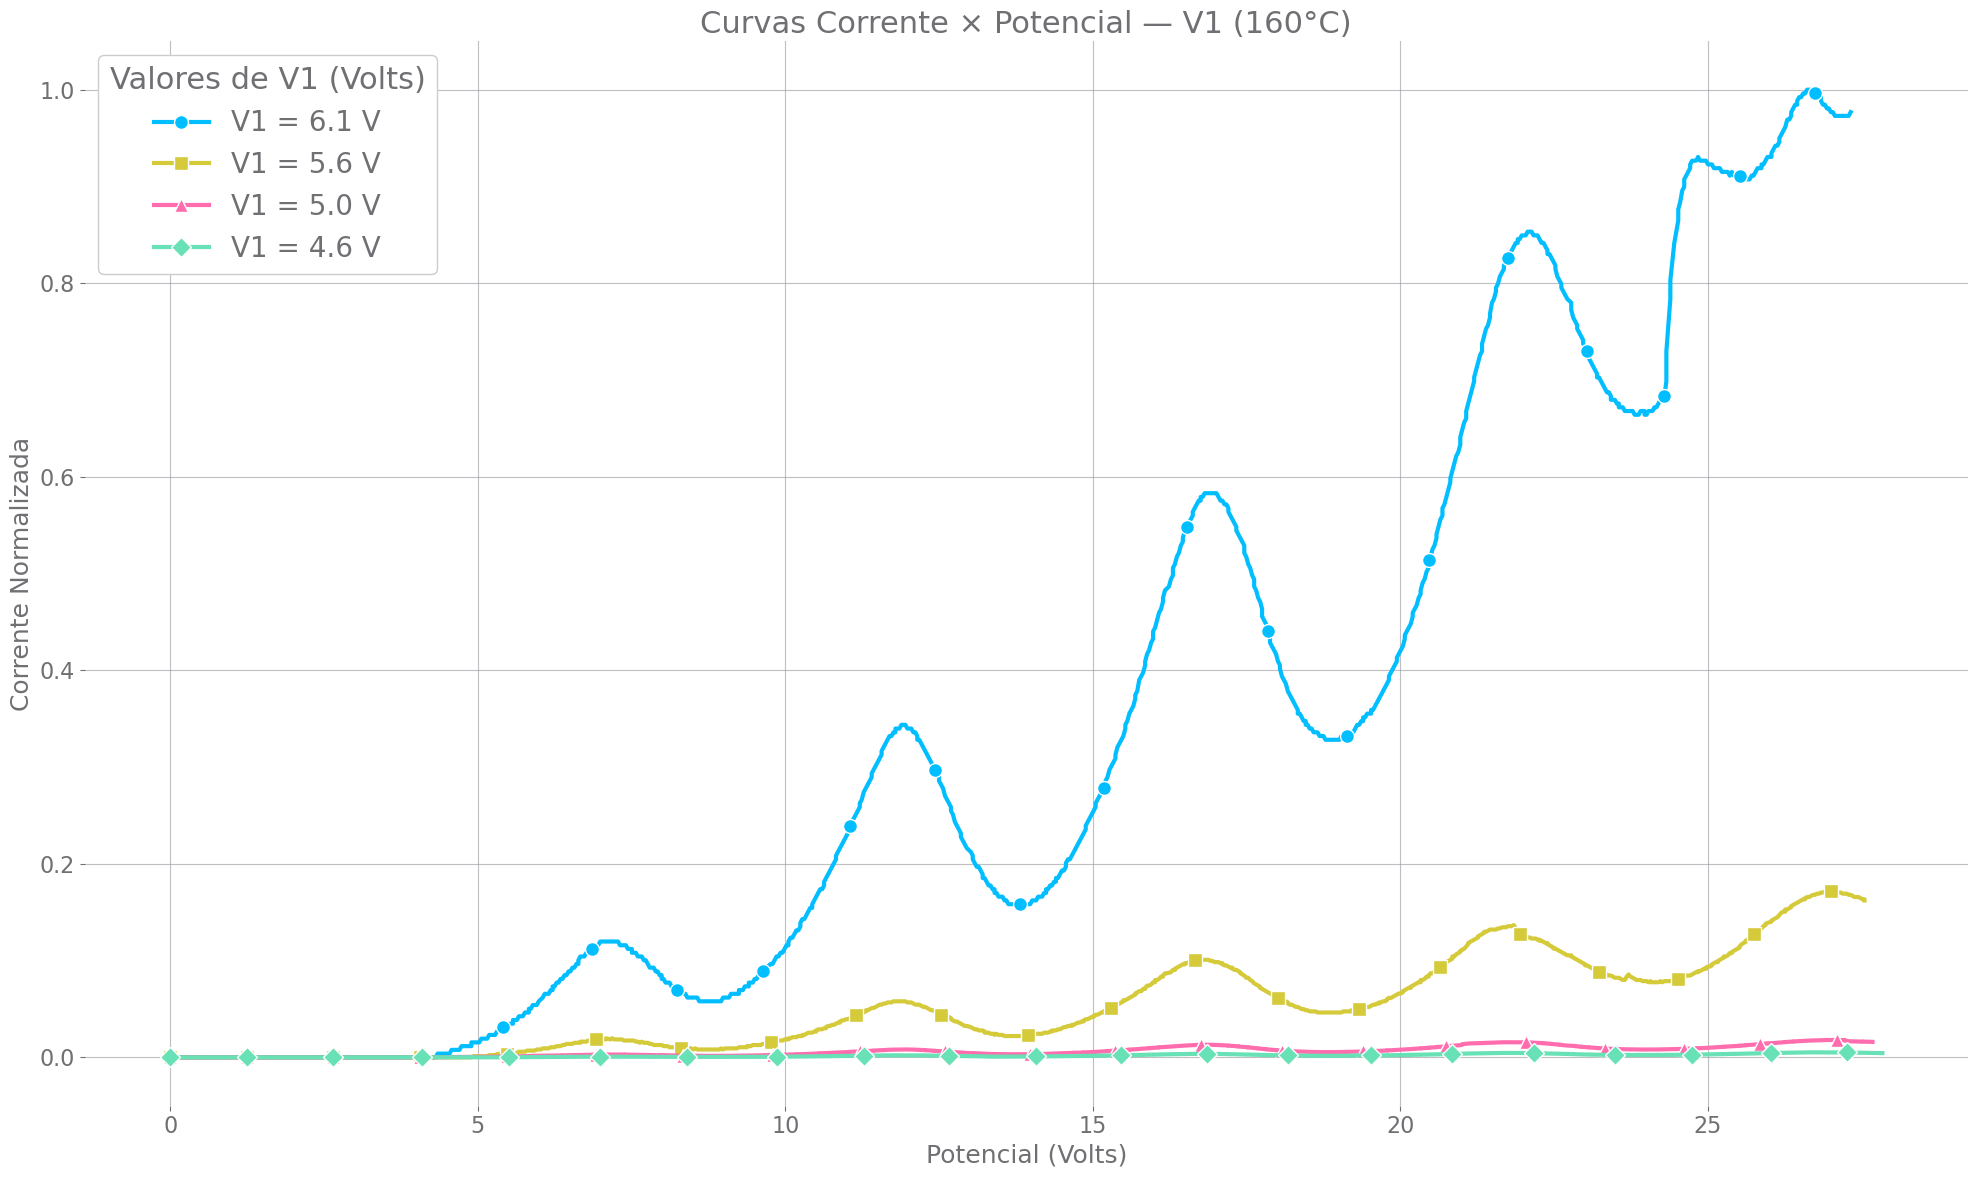

✅ Gráfico salvo em: Resultados/grafico_V1_160C.png


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def gerar_graficos_franck_hertz(caminho_excel, caminho_dados, caminho_saida, tipo, temperatura):
    """
    Gera gráficos de corrente vs potencial normalizados para experimentos de Franck-Hertz.
    
    Parâmetros:
        caminho_excel (str): caminho do arquivo Excel com fatores de escala
        caminho_dados (str): diretório contendo os arquivos de medidas .txt
        caminho_saida (str): diretório onde o gráfico será salvo
        tipo (str): "V1", "V2" ou "V4"
        temperatura (int): temperatura em °C (ex: 150, 160)
    """

    # Lê o arquivo principal (com fatores de escala)
    df_info = pd.read_excel(caminho_excel)

    # Limite de potencial (ajuste se necessário)
    limite_potencial = 30

    # Lista para armazenar dados de cada medida
    dados_medidas = []

    # Loop pelas medidas (1 a 4)
    for medida in range(1, 5):
        nome_arquivo = f"m{medida}-m-e-T_{temperatura}.txt"
        caminho_arquivo = os.path.join(caminho_dados, nome_arquivo)

        if not os.path.exists(caminho_arquivo):
            print(f"Aviso: arquivo {nome_arquivo} não encontrado, pulando...")
            continue

        # Lê o arquivo de dados
        df_dados = pd.read_csv(caminho_arquivo, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (uA)"])

        # Obtém o fator de escala e o valor da coluna (V1, V2, V4)
        linha_info = df_info.loc[df_info["Medida"] == medida]
        escala = linha_info["Escala "].values[0]
        valor_tipo = linha_info[f"{tipo} [Volts]"].values[0]

        # Aplica o fator de escala
        df_dados["Corrente (uA)"] *= escala

        # Filtra até o limite de potencial
        df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

        # Armazena o par (valor_tipo, dataframe)
        dados_medidas.append((valor_tipo, df_dados))

    # Calcula os valores globais de corrente (para normalização)
    todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
    I_min, I_max = todas_correntes.min(), todas_correntes.max()

    # --- Plot ---
    plt.figure(figsize=(20, 12))
    marcadores = ["o", "s", "^", "D", "v", "P", "X"]

    for i, (valor_tipo, df_dados) in enumerate(dados_medidas):
        df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
        marcador = marcadores[i % len(marcadores)]

        plt.plot(
            df_dados["Potencial (V)"],
            df_dados["Corrente Normalizada"],
            label=f"{tipo} = {valor_tipo:.1f} V",
            marker=marcador,
            markevery=50,
            linewidth=3,
            markersize=10
        )

    # Configurações do gráfico
    plt.xlabel("Potencial (Volts)", fontsize=18)
    plt.ylabel("Corrente Normalizada", fontsize=18)
    plt.title(f"Curvas Corrente × Potencial — {tipo} ({temperatura}°C)", fontsize=22)

    plt.legend(
        title=f"Valores de {tipo} (Volts)",
        fontsize=20,
        title_fontsize=22,
        facecolor="white",
        framealpha=1.0
    )

    plt.grid(True)
    plt.tight_layout()

    # --- Salvar o gráfico ---
    if not os.path.exists(caminho_saida):
        os.makedirs(caminho_saida)

    nome_arquivo_saida = f"grafico_{tipo}_{temperatura}C.png"
    caminho_completo = os.path.join(caminho_saida, nome_arquivo_saida)
    plt.show()
    plt.savefig(caminho_completo, dpi=300)
    plt.close()

    print(f"✅ Gráfico salvo em: {caminho_completo}")

gerar_graficos_franck_hertz(
    caminho_excel="Medidas Multiplas Excitações 160°C (Com fator de escala).xlsx",
    caminho_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    caminho_saida="Resultados/",
    tipo="V1",
    temperatura=160
)


## Gráficos em Log

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def gerar_graficos_franck_hertz(
    caminho_excel,
    caminho_dados,
    caminho_saida,
    tipo='V1',
    temperatura=150,
    fator_dist=4,       # ← novo parâmetro (#1)
    fator_prom=0.06     # ← novo parâmetro (#2)
):
    """
    Gera e salva gráficos do experimento de Franck-Hertz.

    Parâmetros:
        caminho_excel (str): Caminho do arquivo Excel com fatores de escala.
        caminho_dados (str): Caminho da pasta contendo os arquivos .txt.
        caminho_saida (str): Pasta onde os gráficos serão salvos.
        tipo (str): 'V1', 'V2' ou 'V4' — define qual conjunto de medidas usar.
        temperatura (int|str): Temperatura usada nos nomes dos arquivos.
        fator_dist (float): Multiplicador do espaçamento mínimo entre vales.
        fator_prom (float): Fator de proeminência mínima relativa.
    """

    # === Lê o arquivo Excel ===
    df = pd.read_excel(caminho_excel)
    display(df.head())

    # === Configuração conforme o tipo ===
    if tipo.upper() == 'V1':
        medidas = range(1, 5)
        limite_potencial = 30
        coluna_v = "V1 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V1)"
    elif tipo.upper() == 'V2':
        medidas = range(5, 9)
        limite_potencial = 22
        coluna_v = "V2 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V2)"
    elif tipo.upper() == 'V4':
        medidas = range(9, 13)
        limite_potencial = 22
        coluna_v = "V4 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V4)"
    else:
        raise ValueError("tipo deve ser 'V1', 'V2' ou 'V4'.")

    # === Lê e processa os arquivos de dados ===
    dados_medidas = []
    for medida in medidas:
        nome_arquivo = f"m{medida}-m-e-T_{temperatura}.txt"
        caminho_arquivo = os.path.join(caminho_dados, nome_arquivo)

        if not os.path.exists(caminho_arquivo):
            print(f"⚠️ Arquivo não encontrado: {caminho_arquivo}")
            continue

        df_dados = pd.read_csv(
            caminho_arquivo,
            sep=r"\s+",
            header=None,
            names=["Potencial (V)", "Corrente (uA)"]
        )

        linha_info = df.loc[df["Medida"] == medida]
        escala = linha_info["Escala "].values[0]
        valor_v = linha_info[coluna_v].values[0]

        df_dados["Corrente (uA)"] *= escala
        df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)
        dados_medidas.append((valor_v, df_dados))

    # === Normalização global ===
    todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
    I_min, I_max = todas_correntes.min(), todas_correntes.max()
    print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

    # === Configurações visuais ===
    marcadores = ["o", "s", "^", "D", "v", "P", "*"]
    marcador_vale = "X"
    cor_vale = "red"

    # === Função interna de plotagem ===
    def plotar_grafico(dados_medidas, mostrar_vales=True):
        plt.figure(figsize=(20, 12))

        for i, (valor_v, df_dados) in enumerate(dados_medidas):
            df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
            V = df_dados["Potencial (V)"].to_numpy()
            I = df_dados["Corrente Normalizada"].to_numpy()

            # Suavização (média móvel)
            I_suave = np.convolve(I, np.ones(5)/5, mode='same')

            # Parâmetros adaptativos (usando variáveis fator_dist e fator_prom)
            dist = int(fator_dist * max(20, len(V)//50) * 1.75)
            prom = fator_prom * (I.max() - I.min())

            # Detecta vales
            vales, _ = find_peaks(-I_suave, distance=dist, prominence=prom)
            vales = vales[V[vales] >= 4.9]

            print(f"Medida {i+1} ({coluna_v}={valor_v:.1f} V): {len(vales)} vales encontrados")

            marcador = marcadores[i % len(marcadores)]
            plt.plot(
                V, I,
                label=f"{coluna_v.split()[0]} = {valor_v:.1f} V",
                marker=marcador,
                markevery=50,
                linewidth=2.5,
                markersize=10
            )

            # --- Marcação e anotações de vales ---
            if mostrar_vales and len(vales) > 1:
                plt.scatter(
                    V[vales], I[vales],
                    color=cor_vale,
                    s=130,
                    marker=marcador_vale,
                    edgecolor="black",
                    linewidth=1.3,
                    zorder=5
                )

                for j in range(len(vales) - 1):
                    x1, x2 = V[vales[j]], V[vales[j + 1]]
                    y1, y2 = I[vales[j]], I[vales[j + 1]]
                    delta_V = x2 - x1
                    x_medio = (x1 + x2) / 2
                    y_medio = (y1 + y2) / 2

                    plt.text(
                        x_medio,
                        y_medio * 1.3,
                        f"ΔV = {delta_V:.2f} V",
                        fontsize=13,
                        color="black",
                        ha="center",
                        va="bottom",
                        fontweight="bold",
                        bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2")
                    )

        plt.xlabel("Potencial (Volts)")
        plt.ylabel("Corrente Normalizada")
        titulo = f"{titulo_base} — {temperatura}°C"
        if mostrar_vales:
            titulo += " — com valores de ΔV"
        else:
            titulo += ""

        plt.title(titulo)
        plt.yscale('log')
        plt.ylim(bottom=2e-4)
        plt.grid(True, which='both', linestyle='--', linewidth=0.7)
        plt.legend(
            title=f"Valores de {coluna_v.split()[0]} (Volts)",
            fontsize=14,
            title_fontsize=16,
            facecolor="white",
            framealpha=1.0
        )
        plt.tight_layout()

        # --- Salva o gráfico ---
        os.makedirs(caminho_saida, exist_ok=True)
        sufixo = "com_vales" if mostrar_vales else "sem_vales"
        nome_arquivo = f"grafico_{tipo.upper()}_{temperatura}C_{sufixo}.png"
        caminho_figura = os.path.join(caminho_saida, nome_arquivo)
        plt.savefig(caminho_figura, dpi=300)
        print(f"💾 Gráfico salvo em: {caminho_figura}")

        plt.show()

    # === Gera e salva os dois gráficos ===
    print(f"\n=== Gráfico COM vales e anotações ({tipo.upper()}, {temperatura}°C) ===")
    plotar_grafico(dados_medidas, mostrar_vales=True)

    print(f"\n=== Gráfico SEM vales ({tipo.upper()}, {temperatura}°C) ===")
    plotar_grafico(dados_medidas, mostrar_vales=False)





,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.09,6.19,0.5,1.000000e-07
1,2,5.63,6.19,0.5,1.000000e-07
2,3,5.01,6.19,0.5,1.000000e-08
3,4,4.61,6.19,0.5,1.000000e-09
4,5,6.09,6.19,0.5,1.000000e-07


Mínimo global: 0.000000000, Máximo global: 0.000034000

=== Gráfico COM vales e anotações (V1, 150°C) ===
Medida 1 (V1 [Volts]=6.1 V): 4 vales encontrados
Medida 2 (V1 [Volts]=5.6 V): 4 vales encontrados
Medida 3 (V1 [Volts]=5.0 V): 4 vales encontrados
Medida 4 (V1 [Volts]=4.6 V): 4 vales encontrados
💾 Gráfico salvo em: Resultados/grafico_V1_150C_com_vales.png


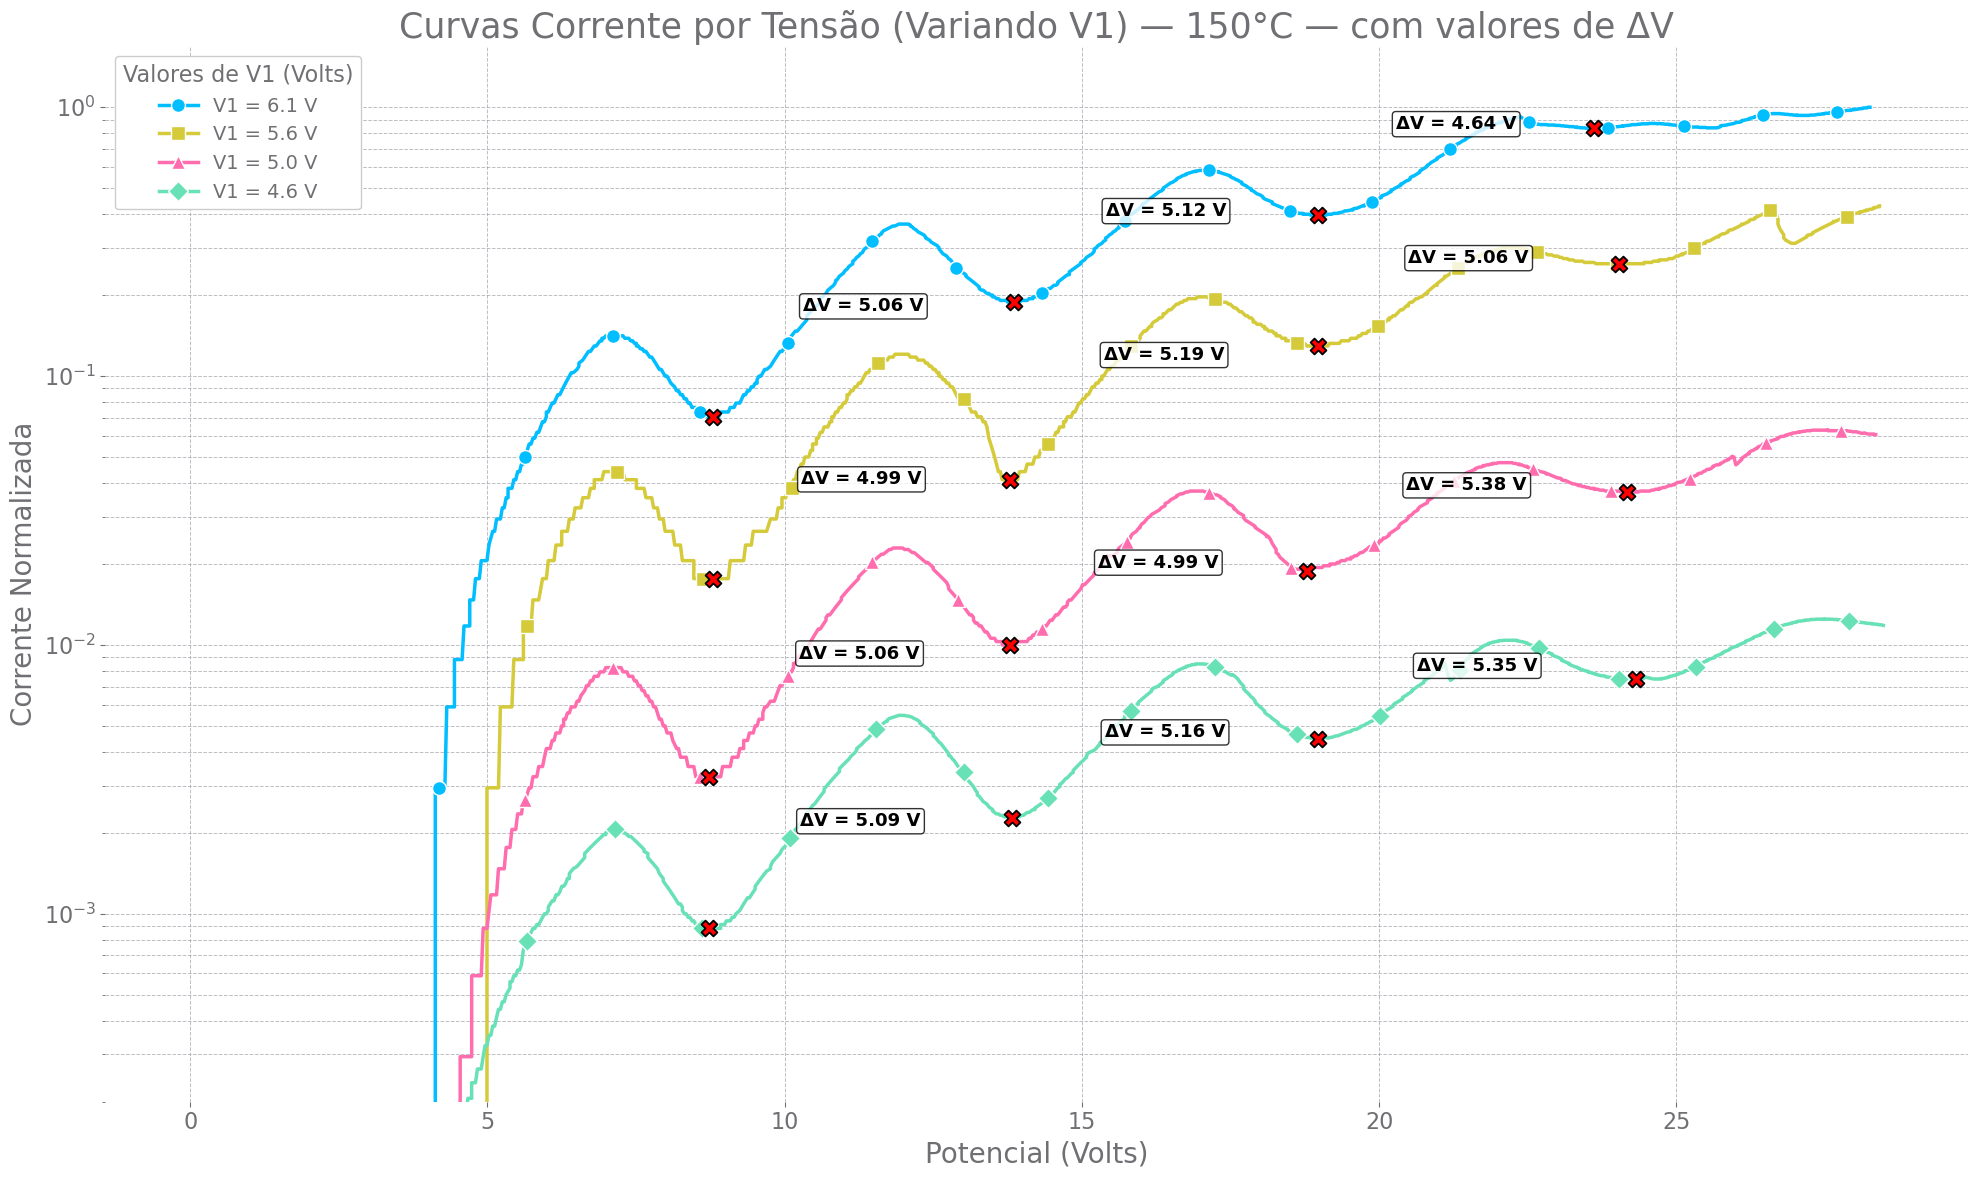


=== Gráfico SEM vales (V1, 150°C) ===
Medida 1 (V1 [Volts]=6.1 V): 4 vales encontrados
Medida 2 (V1 [Volts]=5.6 V): 4 vales encontrados
Medida 3 (V1 [Volts]=5.0 V): 4 vales encontrados
Medida 4 (V1 [Volts]=4.6 V): 4 vales encontrados
💾 Gráfico salvo em: Resultados/grafico_V1_150C_sem_vales.png


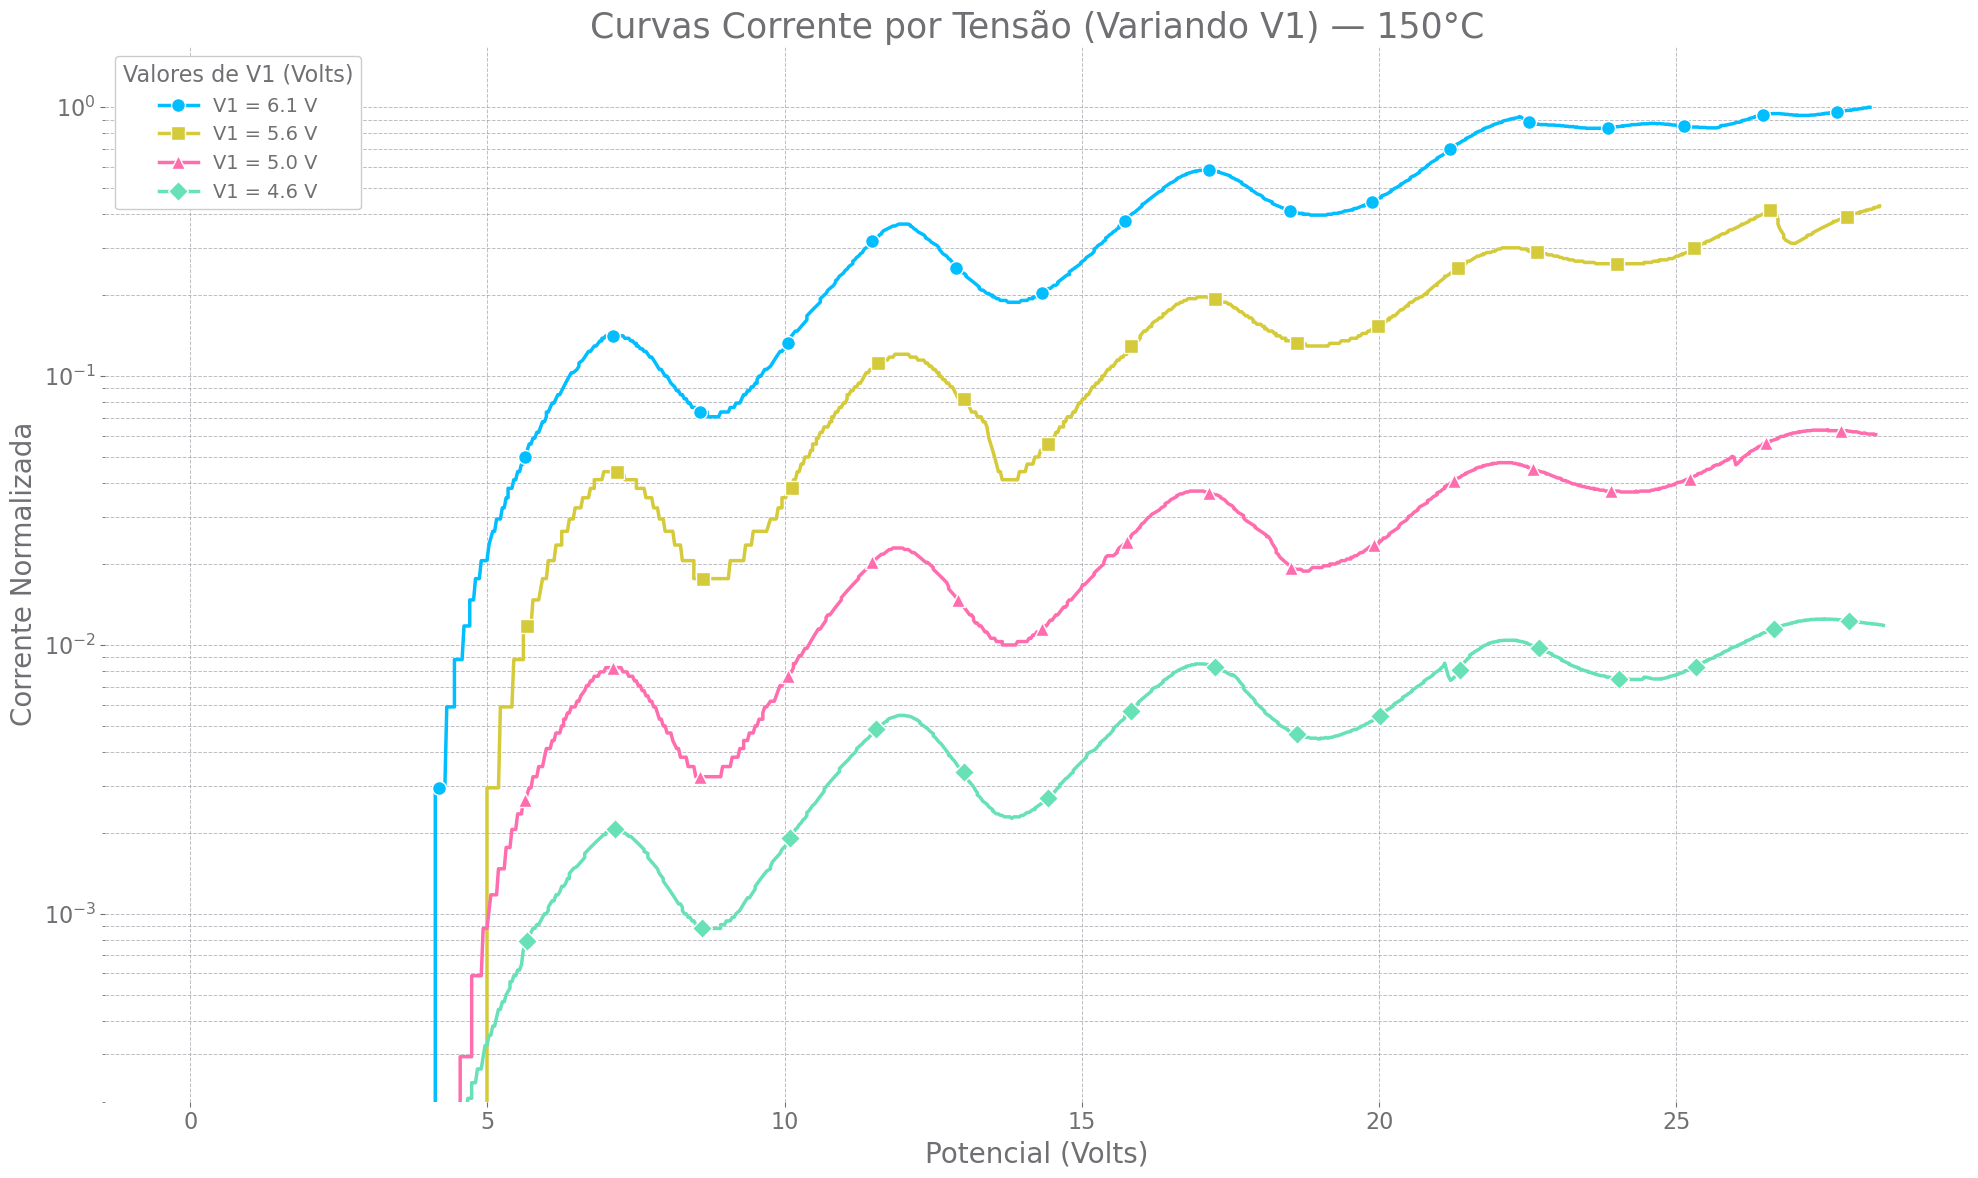

In [ ]:
# Exemplo de uso:
gerar_graficos_franck_hertz(
    caminho_excel="Medidas Multiplas Excitações 150°C (Com fator de escala).xlsx",
    caminho_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    caminho_saida="Resultados/",
    tipo="V1",
    temperatura=140,
    fator_dist=4,
    fator_prom=0.03
)

# Vou comparar os dados obitidos para diferentes temperatuas

,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.1,6.2,0.5,1.000000e-06
1,2,5.6,6.2,0.5,1.000000e-07
2,3,5.0,6.2,0.5,1.000000e-07
3,4,4.6,6.2,0.5,1.000000e-08
4,5,6.1,6.2,0.5,1.000000e-06


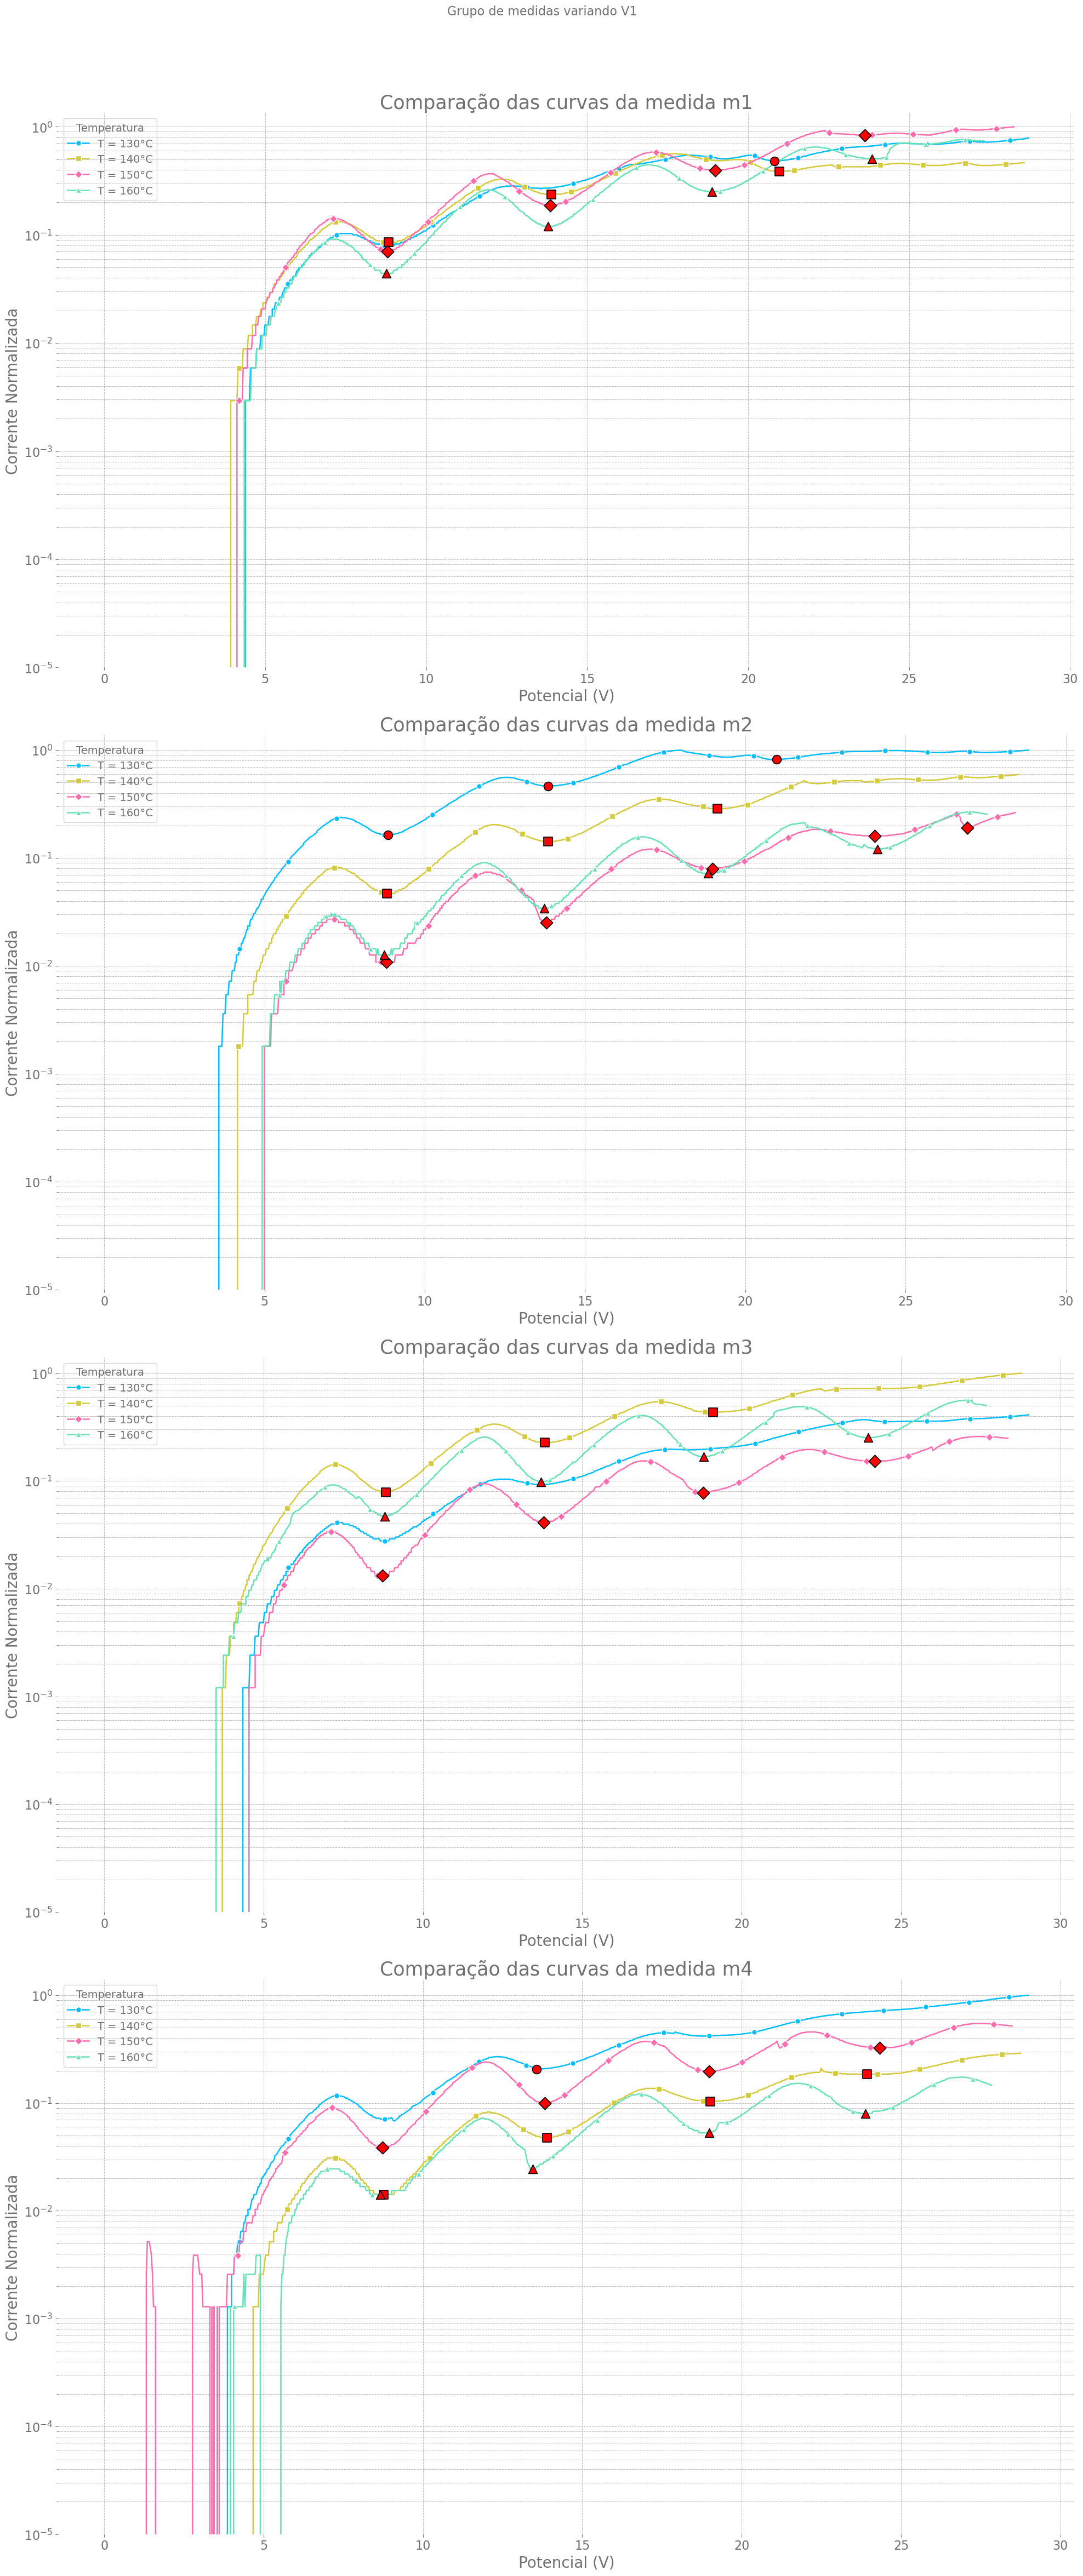

Aviso: arquivo m6-m-e-T_130.txt não encontrado.
Aviso: arquivo m7-m-e-T_160.txt não encontrado.


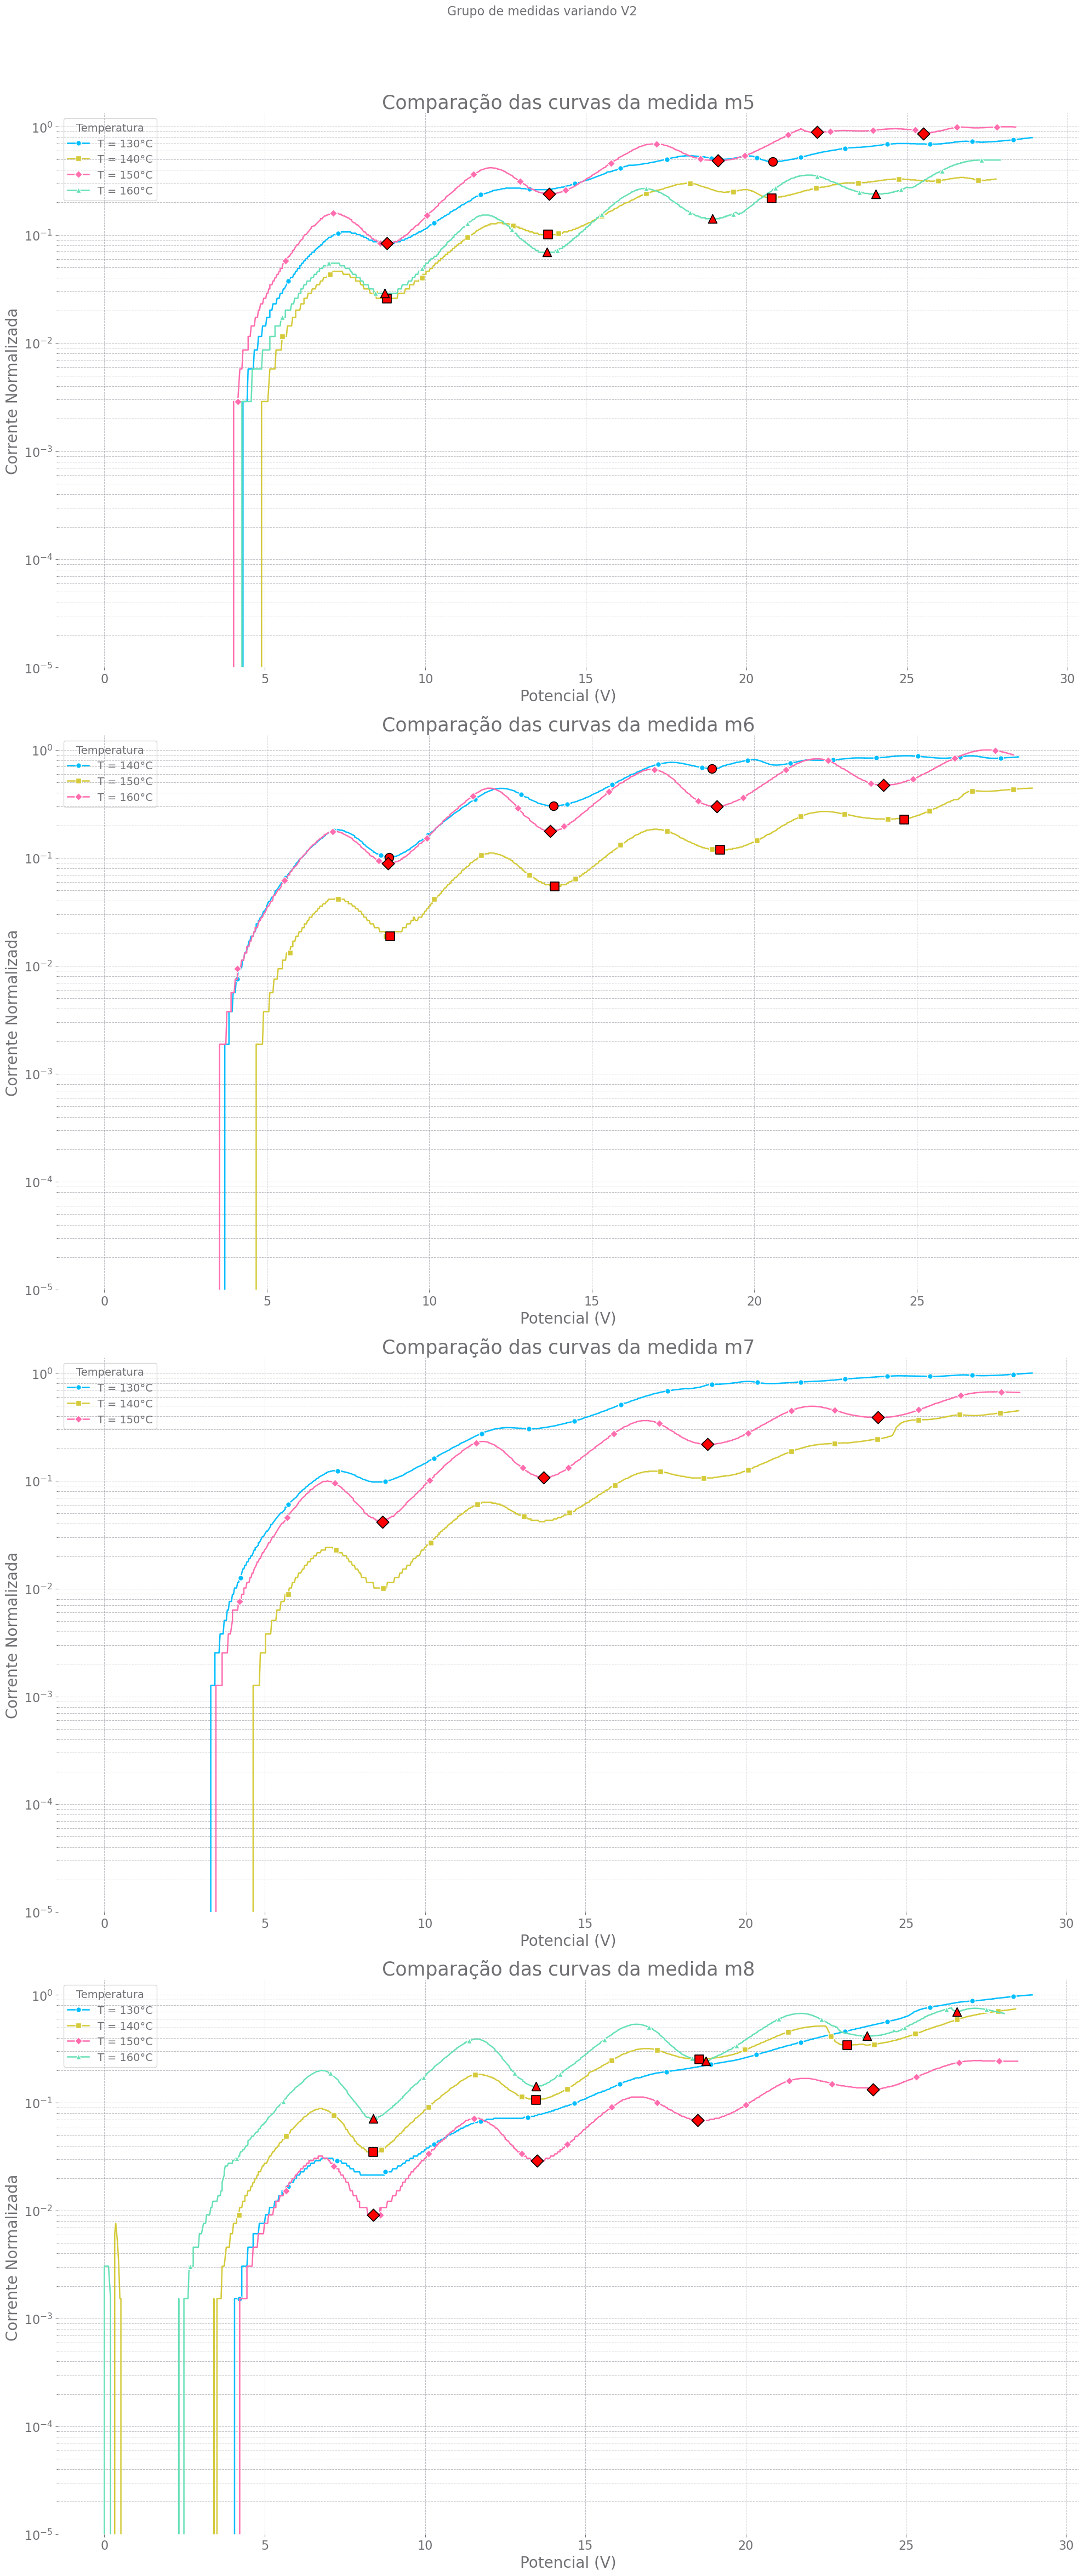

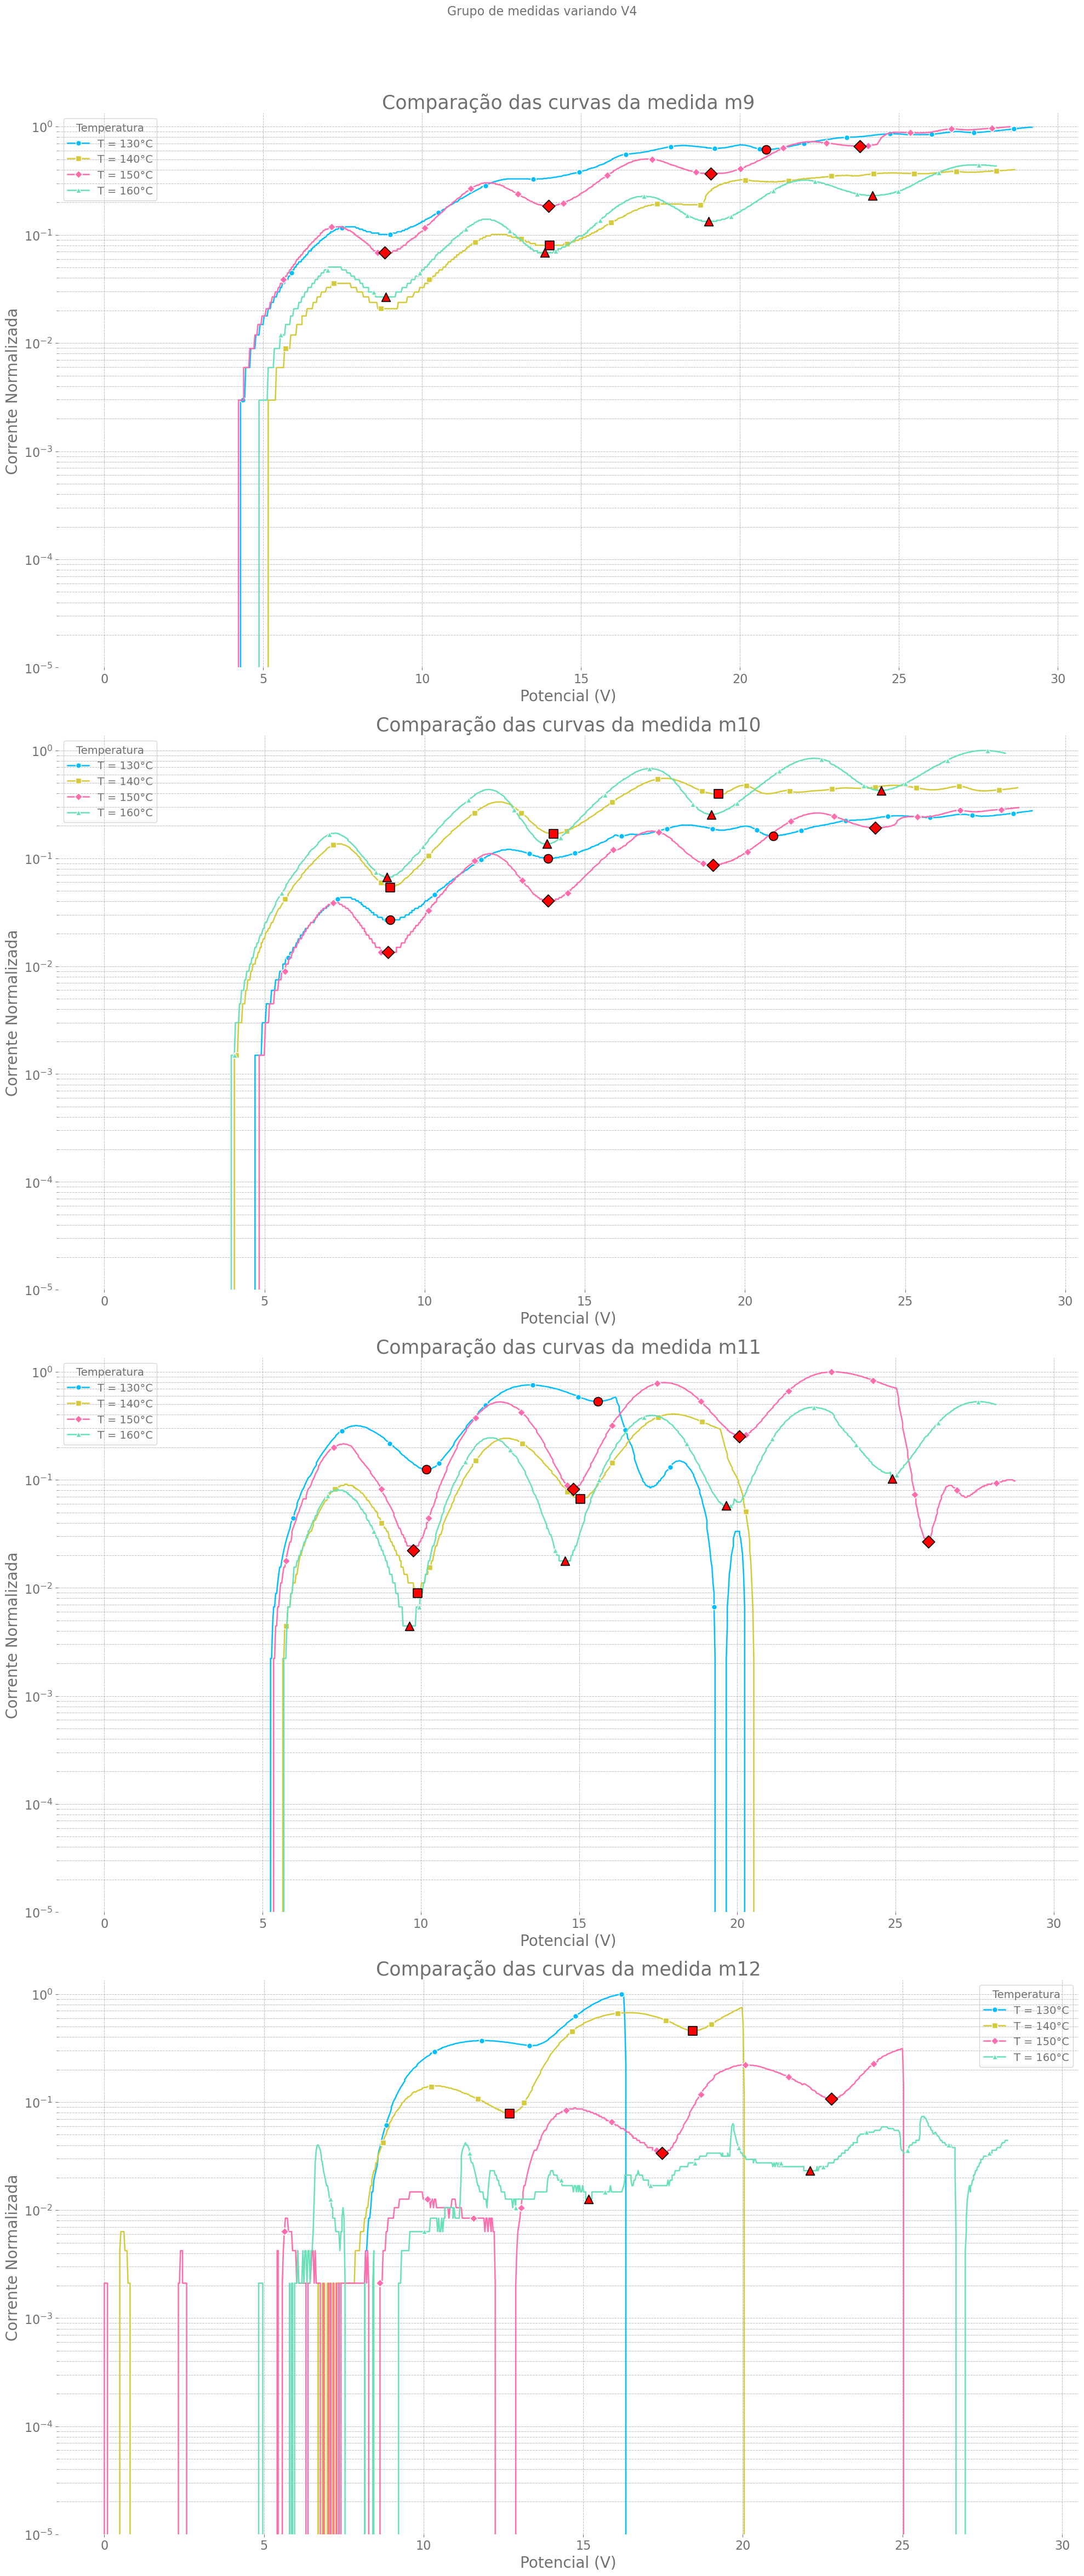

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

# Caminhos fornecidos
caminho_v1 = "Medidas Multiplas Excitações 130°C (Com fator de escala).xlsx"
caminho_v1_dados = "Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v1 = pd.read_excel(caminho_v1)
display(df_v1.head())

# Limite de potencial
limite_potencial = 30

# Faixas de medidas
faixas = {
    "V1": range(1, 5),
    "V2": range(5, 9),
    "V4": range(9, 13)
}

# Temperaturas disponíveis
temperaturas = [130, 140, 150, 160]

# Diferentes marcadores para distinguir as curvas
marcadores = ["o", "s", "D", "^", "v", "P", "X", "*"]

# Função para ler e escalar uma medida
def ler_medida(medida, temperatura):
    nome_arquivo = f"m{medida}-m-e-T_{temperatura}.txt"
    caminho_arquivo = os.path.join(caminho_v1_dados, nome_arquivo)

    if not os.path.exists(caminho_arquivo):
        print(f"Aviso: arquivo {nome_arquivo} não encontrado.")
        return None

    df_dados = pd.read_csv(
        caminho_arquivo, sep=r"\s+", header=None,
        names=["Potencial (V)", "Corrente (uA)"]
    )
    linha_info = df_v1.loc[df_v1["Medida"] == medida]

    if linha_info.empty:
        print(f"Aviso: Medida {medida} não encontrada no arquivo principal (.xlsx).")
        return None

    escala = linha_info["Escala "].values[0]
    df_dados["Corrente (uA)"] *= escala
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)
    return df_dados

# Função de plotagem
def plot_comparacao_medida(medida, ax=None):
    dados_temp = []
    for T in temperaturas:
        df = ler_medida(medida, T)
        if df is not None:
            dados_temp.append((T, df))

    if not dados_temp:
        return None

    # Normalização global
    todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_temp])
    I_min, I_max = todas_correntes.min(), todas_correntes.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    for i, (T, df) in enumerate(dados_temp):
        df["Corrente Normalizada"] = (df["Corrente (uA)"] - I_min) / (I_max - I_min)
        V = df["Potencial (V)"].to_numpy()
        I = df["Corrente Normalizada"].to_numpy()

        # Suavização simples
        I_suave = np.convolve(I, np.ones(5)/5, mode='same')

        # Detecta vales (picos no sinal invertido)
        dist = int(3 * max(20, len(V)//50) * 1.75)
        prom = 0.05 * (I.max() - I.min())
        vales, _ = find_peaks(-I_suave, distance=dist, prominence=prom)

        marcador = marcadores[i % len(marcadores)]

        # --- Curva principal ---
        ax.plot(
            V, I,
            label=f"T = {T}°C",
            marker=marcador,
            markevery=50,
            linewidth=1.8
        )

        # --- Marca os vales ---
        if len(vales) > 0:
            ax.scatter(
                V[vales], I[vales],
                color="red",
                edgecolor="black",
                s=130,
                linewidth=1.2,
                zorder=5,
                marker=marcador  # mesmo marcador da linha
            )

    # --- Configurações visuais ---
    ax.set_xlabel("Potencial (V)")
    ax.set_ylabel("Corrente Normalizada")
    ax.set_yscale("log")
    ax.set_ylim(bottom=1e-5)
    ax.set_title(f"Comparação das curvas da medida m{medida}")
    ax.legend(title="Temperatura")
    ax.grid(True, which='both', linestyle='--', linewidth=0.7)
    return ax

# ---- GERA OS GRÁFICOS ----
for nome, medidas in faixas.items():
    fig, axs = plt.subplots(len(medidas), 1, figsize=(20, 12 * len(medidas)))
    if len(medidas) == 1:
        axs = [axs]
    for ax, medida in zip(axs, medidas):
        plot_comparacao_medida(medida, ax=ax)
    fig.suptitle(f"Grupo de medidas variando {nome}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
